# Problem Set 01 — Chest X-Ray Pneumonia Classification (CNN)

**Task:** Build a CNN to classify pediatric chest X-ray images as **NORMAL** or **PNEUMONIA**.

**How to use this notebook in Google Colab:**
1. Runtime → Change runtime type → GPU
2. Run the cells top to bottom
3. When prompted, mount your Google Drive (the zip you downloaded should be in your Drive, or upload it directly)
4. Update the `ZIP_PATH` variable in the cell below to match where your zip file is located

## 1. Setup: Mount Drive & Unzip Dataset

In [4]:
!pip install -q gdown
import gdown
import zipfile
import os

FILE_ID = '1219EeGE1XTJVXYaulynJSa3BXGsbNCLx'
ZIP_PATH = '/content/Archive.zip'
EXTRACT_PATH = '/content/data'

gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print('Extraction complete. Contents:')
for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=cfce4e18-1663-4b29-8868-cc01607ff6dc
To: /content/Archive.zip
100%|██████████| 1.23G/1.23G [00:14<00:00, 84.0MB/s]


Extraction complete. Contents:
data/
  test/
    NORMAL/
    PNEUMONIA/
  __MACOSX/
    test/
    train/
  train/
    NORMAL/
    PNEUMONIA/
  val/
    NORMAL/
    PNEUMONIA/


## 2. Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Data Loading & Augmentation

Assumes folder structure:
```
data/chest_xray/train/{NORMAL,PNEUMONIA}
data/chest_xray/test/{NORMAL,PNEUMONIA}
data/chest_xray/val/{NORMAL,PNEUMONIA}
```
Update `BASE_DIR` below if the folder names differ after extraction (check the printed tree above).

In [6]:
BASE_DIR = '/content/data'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale'
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', shuffle=False
)

print('Class indices:', train_gen.class_indices)



Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## 4. Handle Class Imbalance

The dataset has noticeably more PNEUMONIA images than NORMAL. We compute class weights so the model doesn't just learn to predict the majority class.

In [7]:
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


## 5. Build the CNN Model

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,847,809 (7.05 MB)

 Trainable params: 1,847,105 (7.05 MB)

 Non-trainable params: 704 (2.75 KB)

## 6. Train the Model

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS = 20

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 293ms/step - accuracy: 0.8666 - loss: 0.3245 - precision: 0.9543 - recall: 0.8617 - val_accuracy: 0.5000 - val_loss: 3.5311 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 46s 282ms/step - accuracy: 0.9064 - loss: 0.2322 - precision: 0.9695 - recall: 0.9025 - val_accuracy: 0.5000 - val_loss: 6.6652 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 279ms/step - accuracy: 0.9197 - loss: 0.1940 - precision: 0.9760 - recall: 0.9143 - val_accuracy: 0.5000 - val_loss: 6.0952 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 264ms/step - accuracy: 0.9262 - loss: 0.1882 - precision: 0.9791 - recall: 0.9203 - val_accuracy: 0.5625 - val_loss: 1.3967 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━

## 7. Plot Training History

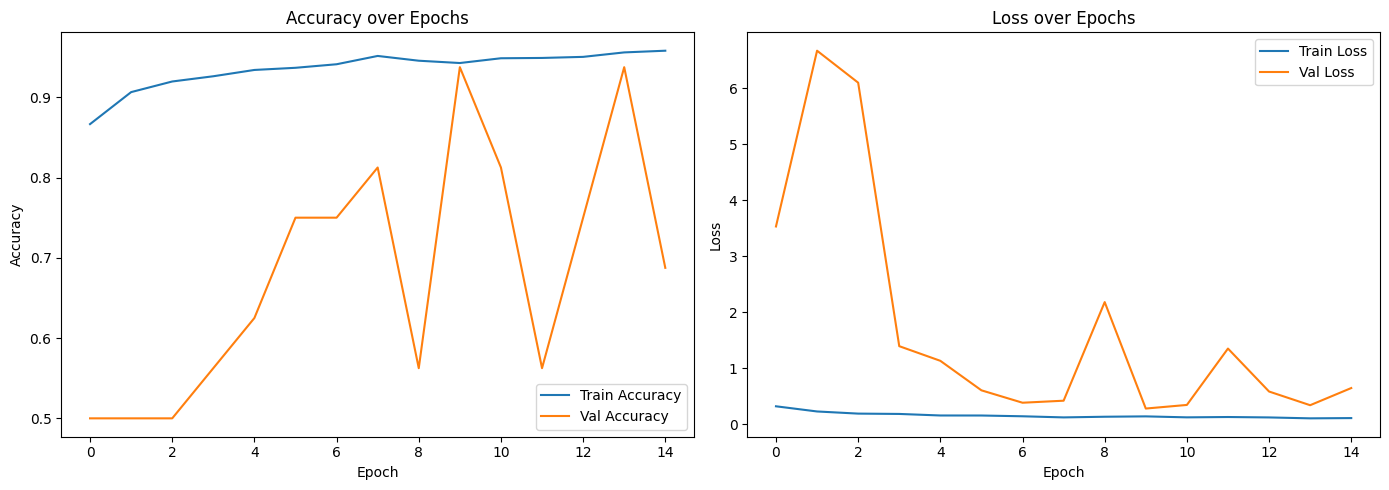

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## 8. Evaluate on Test Set

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.9087 - loss: 0.2549 - precision: 0.9071 - recall: 0.9513
Test Accuracy: 0.9087
Test Precision: 0.9071
Test Recall: 0.9513
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.84      0.87       234
   PNEUMONIA       0.91      0.95      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



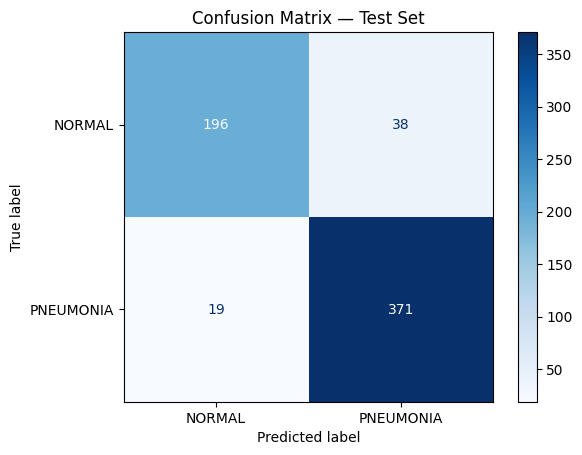

In [11]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_gen)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Precision: {test_prec:.4f}')
print(f'Test Recall: {test_rec:.4f}')

pred_probs = model.predict(test_gen)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print('\nClassification Report:')
print(classification_report(true_labels, pred_labels, target_names=class_names))

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 9. Save the Model

Copy the classification report numbers, and the two saved PNG plots, into your README.md findings section.

In [12]:
model.save('chest_xray_cnn_model.h5')
print('Model saved as chest_xray_cnn_model.h5')

Model saved as chest_xray_cnn_model.h5


In [13]:
from google.colab import files
files.download('training_history.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
files.download('chest_xray_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>